In [1]:
"""Estimating the background count rate from inter-photon times
============================================================

Every burst-analysis quantity that is corrected for background — burst size,
FRET efficiency, stoichiometry — needs the background rate first, and the
cleanest place to read it is the *inter-photon time* distribution: for a
Poisson background the gaps are exponential with rate :math:`\\lambda`, and
the bursts, being much brighter, only ever shorten gaps. So the **long gaps
belong to the background alone**.

`tttrlib.estimate_background_rate` is the exponential-tail maximum-likelihood
estimator FRETBursts uses (``expon_fit``): keep the largest ``tail_fraction``
of the sorted inter-photon times, subtract the threshold at which the tail
starts (an exponential's upper tail is *threshold + Exp(λ)*), and

.. math::

    \\hat\\lambda = \\frac{N_{\\rm tail}}{\\sum_{i \\in \\rm tail} (t_i - t_{\\rm thr})}.

Times go in as **milliseconds**, the rate comes back in **kHz** — typical
single-molecule background is 0.2–3 kHz. This example simulates a Poisson
background with bursts mixed in and shows why the naive :math:`1/\\overline{t}`
over-estimates while the tail MLE does not, and how the choice of
``tail_fraction`` trades bias for variance.
"""
import numpy as np
import matplotlib.pyplot as plt

import tttrlib

rng = np.random.default_rng(1)

In [2]:
# Simulate: 1.2 kHz background over 20 s, plus 300 bursts of ~1 ms at 40 kHz
bg_khz = 1.2
duration_s = 20.0
t = [rng.uniform(0, duration_s, rng.poisson(bg_khz * 1e3 * duration_s))]
for t0 in rng.uniform(0, duration_s, 300):
    t.append(rng.uniform(t0, t0 + 1e-3, rng.poisson(40e3 * 1e-3)))
t = np.sort(np.concatenate(t))
ipt_ms = np.diff(t) * 1e3                       # inter-photon times in ms
print(f"{t.size} photons, of which {t.size - int(bg_khz * 1e3 * duration_s)} in bursts (roughly)")

35838 photons, of which 11838 in bursts (roughly)


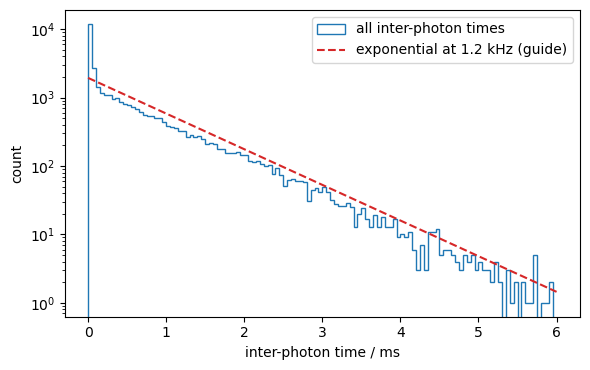

In [3]:
# The gap distribution: an exponential floor from the background with a
# spike of short gaps from the bursts.
fig, ax = plt.subplots(figsize=(6, 3.8))
bins = np.linspace(0, 6, 121)
ax.hist(ipt_ms, bins=bins, histtype="step", lw=1.5, label="all inter-photon times")
lam = bg_khz  # 1/ms
ax.plot(bins, ipt_ms.size * (bins[1] - bins[0]) * lam * np.exp(-lam * bins) * 0.9,
        color="C3", ls="--", label=f"exponential at {bg_khz} kHz (guide)")
ax.set_yscale("log")
ax.set_xlabel("inter-photon time / ms")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()

tail_fraction 1.00:  1.792 kHz
tail_fraction 0.80:  1.479 kHz
tail_fraction 0.50:  1.207 kHz
tail_fraction 0.30:  1.188 kHz
tail_fraction 0.20:  1.191 kHz
tail_fraction 0.10:  1.224 kHz
tail_fraction 0.05:  1.254 kHz
truth 1.200 kHz, naive 1/mean 1.792 kHz


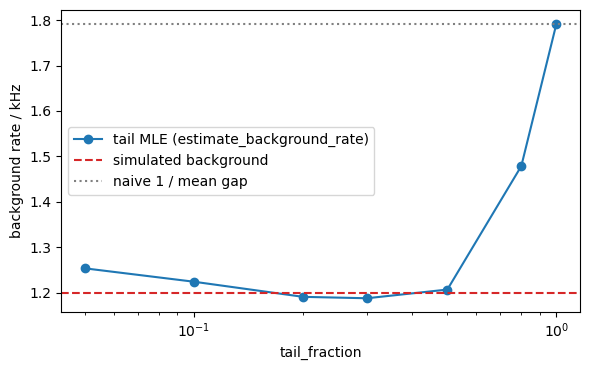

In [4]:
# The estimate as a function of the tail fraction
# -----------------------------------------------
# tail_fraction = 1 is the whole-sample MLE, i.e. 1/mean -- pulled up by the
# burst gaps. Small fractions use only the longest gaps, which are pure
# background: unbiased, but noisier because fewer gaps enter.
fractions = [1.0, 0.8, 0.5, 0.3, 0.2, 0.1, 0.05]
est = [tttrlib.estimate_background_rate(ipt_ms.tolist(), 0.1, f) for f in fractions]
naive = 1.0 / ipt_ms.mean()
for f, e in zip(fractions, est):
    print(f"tail_fraction {f:4.2f}: {e:6.3f} kHz")
print(f"truth {bg_khz:.3f} kHz, naive 1/mean {naive:.3f} kHz")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(fractions, est, "o-", label="tail MLE (estimate_background_rate)")
ax.axhline(bg_khz, color="C3", ls="--", label="simulated background")
ax.axhline(naive, color="0.5", ls=":", label="naive 1 / mean gap")
ax.set_xscale("log")
ax.set_xlabel("tail_fraction")
ax.set_ylabel("background rate / kHz")
ax.legend()
fig.tight_layout()

In [5]:
# Bias-variance over many realisations: the default tail_fraction = 0.5 is a
# good compromise on a bursty stream like this one.
reps = 40
table = {f: [] for f in (1.0, 0.5, 0.2, 0.05)}
for r in range(reps):
    rr = np.random.default_rng(100 + r)
    tt = [rr.uniform(0, duration_s, rr.poisson(bg_khz * 1e3 * duration_s))]
    for t0 in rr.uniform(0, duration_s, 300):
        tt.append(rr.uniform(t0, t0 + 1e-3, rr.poisson(40e3 * 1e-3)))
    gaps = np.diff(np.sort(np.concatenate(tt))) * 1e3
    for f in table:
        table[f].append(tttrlib.estimate_background_rate(gaps.tolist(), 0.1, f))
for f, v in table.items():
    v = np.asarray(v)
    print(f"tail_fraction {f:4.2f}: mean {v.mean():.3f} kHz (bias {v.mean() - bg_khz:+.3f}), sd {v.std():.3f}")
plt.show()

tail_fraction 1.00: mean 1.801 kHz (bias +0.601), sd 0.009
tail_fraction 0.50: mean 1.216 kHz (bias +0.016), sd 0.011
tail_fraction 0.20: mean 1.218 kHz (bias +0.018), sd 0.017
tail_fraction 0.05: mean 1.224 kHz (bias +0.024), sd 0.034
